In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PINN_live_wire import PINN, u_analytic, R_ext, device
from FEM_live_wire import nodes, u_fem
from scipy.interpolate import griddata

Выбрано: cuda


d:\Practice\PINN_model\venv\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | LR: 1.0e-03 | Loss: 1.9382 | Loss_integral: 0.2267 | | Loss_bc: 0.0057 | Error: 0.2116
Epoch  1000 | LR: 1.0e-03 | Loss: -1.2866 | Loss_integral: -1.3002 | | Loss_bc: 0.0000 | Error: 0.0281
Epoch  2000 | LR: 1.0e-03 | Loss: -1.4335 | Loss_integral: -1.4436 | | Loss_bc: 0.0000 | Error: 0.0065
Epoch  3000 | LR: 1.0e-04 | Loss: -1.4517 | Loss_integral: -1.4601 | | Loss_bc: 0.0000 | Error: 0.0045
Epoch  4000 | LR: 1.0e-04 | Loss: -1.4518 | Loss_integral: -1.4611 | | Loss_bc: 0.0000 | Error: 0.0040
Epoch  5000 | LR: 1.0e-05 | Loss: -1.4560 | Loss_integral: -1.4649 | | Loss_bc: 0.0000 | Error: 0.0038
Epoch  6000 | LR: 1.0e-05 | Loss: -1.4549 | Loss_integral: -1.4632 | | Loss_bc: 0.0000 | Error: 0.0037
Epoch  7000 | LR: 1.0e-05 | Loss: -1.4529 | Loss_integral: -1.4616 | | Loss_bc: 0.0000 | Error: 0.0037

Time 118.9050 сек
Final error (PINN): 3.6053e-03
Выбрано: cuda
Время: 3.7945 сек
Error: 3.0189e-03


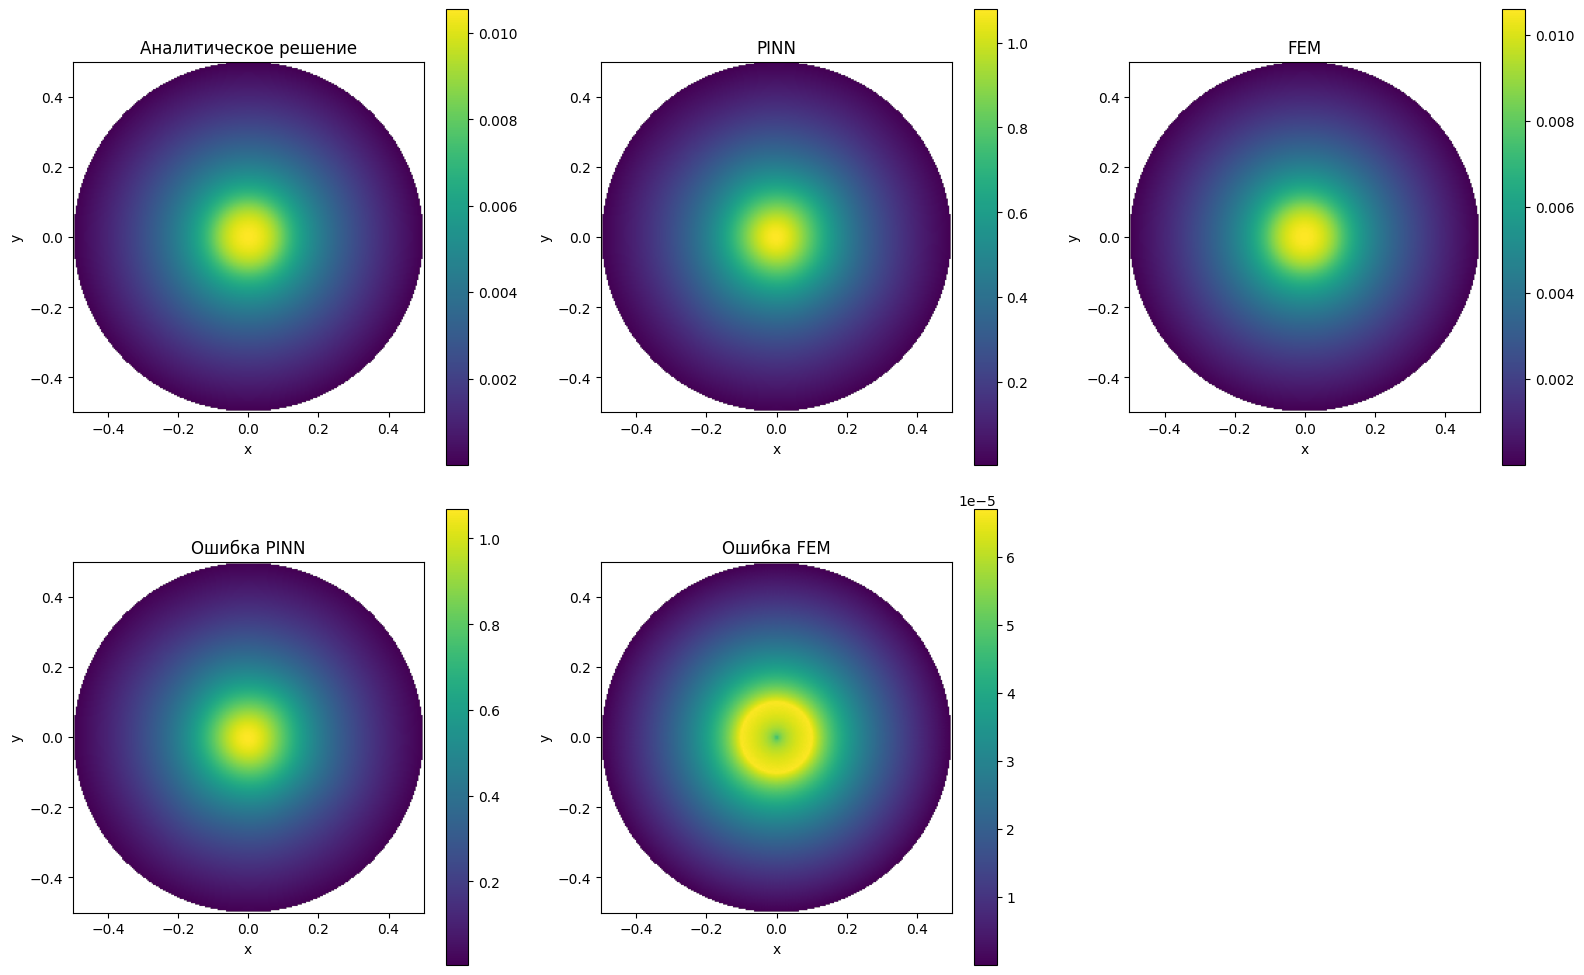

In [ ]:
model = PINN().to(device)
model.load_state_dict(torch.load("pinn_poisson.pth", map_location=device))
model.eval()

N = 250

x = torch.linspace(-R_ext, R_ext, N, device=device)
y = torch.linspace(-R_ext, R_ext, N, device=device)

X, Y = torch.meshgrid(x, y, indexing='ij')

r = torch.sqrt(X**2 + Y**2)
mask = r <= R_ext

x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    U_true = u_analytic(x_flat, y_flat).reshape(N, N)

with torch.no_grad():
    U_pinn = model(x_flat, y_flat).reshape(N, N)

err_pinn = torch.abs(U_true - U_pinn)

nodes_np = nodes.cpu().numpy()
u_fem_np = u_fem.cpu().numpy()

points = np.stack([
    X.cpu().numpy().flatten(),
    Y.cpu().numpy().flatten()
], axis=1)

#интерполяция между узлами
U_fem_grid = griddata( 
    nodes_np, #координаты узлов
    u_fem_np, #значение решения в узлах
    points,   #сами точки
    method='linear',
    fill_value=np.nan
)

U_fem_grid = U_fem_grid.reshape(N, N) 

err_fem = np.abs(U_true.cpu().numpy() - U_fem_grid)

mask_np = mask.cpu().numpy()

U_true_np = U_true.cpu().numpy()
U_pinn_np = U_pinn.cpu().numpy()
err_pinn_np = err_pinn.cpu().numpy()

U_true_np[~mask_np] = np.nan  #все точки вне круга NaN
U_pinn_np[~mask_np] = np.nan
err_pinn_np[~mask_np] = np.nan

U_fem_grid[~mask_np] = np.nan
err_fem[~mask_np] = np.nan

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

plots = [
    (U_true_np, "Аналитическое решение"),
    (U_pinn_np, "PINN"),
    (U_fem_grid, "FEM"),
    (err_pinn_np, "Ошибка PINN"),
    (err_fem, "Ошибка FEM"),
]

for i, (data, title) in enumerate(plots):

    row = i // 3
    col = i % 3

    im = ax[row, col].imshow(
        data.T,
        extent=[-R_ext, R_ext, -R_ext, R_ext],
        origin='lower',
        cmap='viridis'
    )

    ax[row, col].set_title(title)
    ax[row, col].set_xlabel("x")
    ax[row, col].set_ylabel("y")

    plt.colorbar(im, ax=ax[row, col])

ax[1, 2].axis('off')

plt.tight_layout()
plt.show()